# 01 — 数据探索与概览

> MAZU 沙特多灾种预警智能体 · Phase 0 数据探索

本 Notebook 目标：
- 了解 365 个 NetCDF 指标文件的结构（变量、维度、时空覆盖）
- 掌握变量的物理含义分类和数值分布
- 检查缺失值、异常值情况
- 分析灾害标签（`flash_flood_risk`）的时空分布和不平衡程度

In [ ]:
# ============================================
# 1. 导入库与路径设置
# ============================================
import sys
sys.path.insert(0, '..')

import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm

# 自动重载本地模块（改完 .py 无需重启 Kernel）
%load_ext autoreload
%autoreload 2

from data.loader import load_single_day, load_date_range, get_variable_list, get_variable_info
from config.settings import INDICATORS_DIR, DISASTER_TYPES

# ---- 中文字体设置 ----
def setup_chinese_font():
    """自动检测并使用可用的中文字体，解决图表中文方框问题。"""
    available_fonts = {f.name for f in fm.fontManager.ttflist}
    # 按优先级尝试
    candidates = ['Microsoft YaHei', 'SimHei', 'Noto Sans SC', 'STXihei', 'STHeiti']
    for font in candidates:
        if font in available_fonts:
            plt.rcParams['font.sans-serif'] = [font, 'DejaVu Sans', 'Arial']
            plt.rcParams['axes.unicode_minus'] = False
            print(f'   ✅ 使用字体: {font}')
            return font
    # 兜底
    print('   ⚠️ 未找到中文字体，图表中文可能显示为方框')
    plt.rcParams['axes.unicode_minus'] = False
    return None

setup_chinese_font()

# 绘图设置
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10

print('✅ 库导入成功')
print(f'   指标目录: {INDICATORS_DIR}')
print(f'   灾害类型: {DISASTER_TYPES}')

   ✅ 使用字体: Microsoft YaHei
✅ 库导入成功
   指标目录: d:\College\Semester-3\mazu_saudi_ewai\indicators
   灾害类型: ['flash_flood', 'extreme_heat', 'dust_wind', 'coastal_wave']


---

## 2. 数据文件概览

检查指标文件的数量、日期覆盖范围和单个文件的结构。

In [21]:
# 文件数量与日期覆盖
files = sorted(glob.glob(os.path.join(INDICATORS_DIR, 'saudi_indicators_*.nc')))
print(f'📁 文件总数: {len(files)}')
print(f'   首文件: {os.path.basename(files[0])}')
print(f'   末文件: {os.path.basename(files[-1])}')

# 检查日期连续性
dates = []
for f in files:
    d = os.path.basename(f).replace('saudi_indicators_', '').replace('.nc', '')
    dates.append(pd.Timestamp(d))

expected = pd.date_range(dates[0], dates[-1], freq='D')
actual = pd.DatetimeIndex(dates)
missing_days = expected.difference(actual)
print(f'   日期连续性: {"✅ 无缺失" if len(missing_days) == 0 else f"❌ 缺失 {len(missing_days)} 天"}')

# 单个文件结构
ds_sample = load_single_day('2025-06-15')
print(f'\n📊 单文件结构 (以 2025-06-15 为例):')
print(f'   变量数: {len(ds_sample.data_vars)}')
print(f'   经度格点数: {ds_sample.sizes["longitude"]}')
print(f'   纬度格点数: {ds_sample.sizes["latitude"]}')
print(f'   总格点数: {ds_sample.sizes["latitude"] * ds_sample.sizes["longitude"]}')
print(f'   时间步: {ds_sample.sizes.get("time", 1)} (6-hourly)')
print(f'   文件大小估算: {ds_sample.nbytes / 1024 / 1024:.1f} MB')

📁 文件总数: 365
   首文件: saudi_indicators_20250101.nc
   末文件: saudi_indicators_20251231.nc
   日期连续性: ✅ 无缺失

📊 单文件结构 (以 2025-06-15 为例):
   变量数: 91
   经度格点数: 220
   纬度格点数: 160
   总格点数: 35200
   时间步: 4 (6-hourly)
   文件大小估算: 15.0 MB


---

## 3. 变量分类

91 个变量按物理含义分为九大类，方便后续按灾害类型取用。

In [22]:
# 按物理含义将 91 个变量分组
variable_groups = {
    '🌧️ 降水相关': [
        'daily_precip_total', 'daily_convective_precip', 'daily_large_scale_precip',
        'monthly_precip_total', 'monthly_precip_mmday', 'monthly_convective_precip',
        'monthly_large_scale_precip', 'monthly_convective_precip_ratio',
        'precip_mmday', 'convective_precip_ratio',
        'ds10_daily_total', 'ds10_max_30min', 'ds10_max_1h', 'ds10_max_3h', 'ds10_max_6h',
        'ds10_rainy_steps', 'ds10_ds2_precip_diff', 'ds10_ds2_precip_ratio',
        'ds10_ds2_heavy_rain_overlap',
        'daily_precip_climatology', 'daily_precip_anomaly', 'daily_precip_anomaly_ratio',
    ],
    '🌡️ 温度与热相关': [
        't2m_c', 't2m_anomaly_c', 't2m_climatology_c',
        'tmax_c', 'tmax_anomaly_c', 'tmax_climatology_c',
        'tmin_c', 'diurnal_temp_range_c', 'd2m_c', 'dewpoint_depression_c',
        'heat_index_c', 'apparent_temp_c', 'heat_stress_index',
        'heatwave_day_flag', 'heatwave_duration_days',
    ],
    '💧 湿度与水汽': [
        'rh2m', 'sh2m', 'vpd_kpa', 'qmax_2m', 'qmin_2m',
        'pwat', 'ivt', 'ivt_u', 'ivt_v', 'ivt_divergence', 'ivt_convergence',
        'moisture_transport925', 'moisture_transport850',
    ],
    '💨 风场': [
        'wind10_speed', 'wind925_speed', 'wind850_speed',
        'jet300_speed', 'jet200_speed',
        'wind_shear_850_300', 'wind_shear_850_200',
        'monthly_wind_stress_mag', 'monthly_orographic_stress',
    ],
    '⛈️ 对流与不稳定': [
        'cape', 'cin', 'surface_lifted_index', 'best_lifted_index',
        'relative_vorticity850', 'divergence850', 'absolute_vorticity850',
        'omega700', 'omega500', 'geopotential_height500',
    ],
    '☀️ 辐射与能量': [
        'sw_net', 'lw_net', 'net_radiation', 'bowen_ratio',
        'monthly_sw_net', 'monthly_lw_net', 'monthly_net_radiation',
        'monthly_bowen_ratio', 'monthly_uvb_flux', 'monthly_uvb_clear_ratio',
        'monthly_heat_stress_index',
    ],
    '☁️ 云量': ['total_cloud_cover', 'low_cloud_cover', 'middle_cloud_cover', 'high_cloud_cover'],
    '🌊 海洋': ['sst_celsius'],
    '🏔️ 地形与地表': ['orography', 'surface_pressure'],
    '⚠️ 灾害标签': ['flash_flood_risk'],
}

for group, vars_list in variable_groups.items():
    available = [v for v in vars_list if v in ds_sample.data_vars]
    print(f'\n{group} ({len(available)} 个)')
    for v in available:
        print(f'    {v}')


🌧️ 降水相关 (22 个)
    daily_precip_total
    daily_convective_precip
    daily_large_scale_precip
    monthly_precip_total
    monthly_precip_mmday
    monthly_convective_precip
    monthly_large_scale_precip
    monthly_convective_precip_ratio
    precip_mmday
    convective_precip_ratio
    ds10_daily_total
    ds10_max_30min
    ds10_max_1h
    ds10_max_3h
    ds10_max_6h
    ds10_rainy_steps
    ds10_ds2_precip_diff
    ds10_ds2_precip_ratio
    ds10_ds2_heavy_rain_overlap
    daily_precip_climatology
    daily_precip_anomaly
    daily_precip_anomaly_ratio

🌡️ 温度与热相关 (15 个)
    t2m_c
    t2m_anomaly_c
    t2m_climatology_c
    tmax_c
    tmax_anomaly_c
    tmax_climatology_c
    tmin_c
    diurnal_temp_range_c
    d2m_c
    dewpoint_depression_c
    heat_index_c
    apparent_temp_c
    heat_stress_index
    heatwave_day_flag
    heatwave_duration_days

💧 湿度与水汽 (13 个)
    rh2m
    sh2m
    vpd_kpa
    qmax_2m
    qmin_2m
    pwat
    ivt
    ivt_u
    ivt_v
    ivt_divergence
    ivt_

---

## 4. 缺失值分析

抽样 12 个月（每月 15 号），统计每个变量的 NaN 比例。

=== 缺失率最高的变量 TOP 15 ===
                       variable  avg_nan_pct  max_nan_pct
                   precip_mmday   100.000000   100.000000
        convective_precip_ratio   100.000000   100.000000
          ds10_ds2_precip_ratio    91.097222    99.514205
                    sst_celsius    83.645362    83.645362
monthly_convective_precip_ratio    64.884233    97.136364
     daily_precip_anomaly_ratio    59.008759   100.000000
                        qmin_2m     0.013731     0.133523
                 monthly_sw_net     0.000000     0.000000
                 monthly_lw_net     0.000000     0.000000
          monthly_net_radiation     0.000000     0.000000
      monthly_heat_stress_index     0.000000     0.000000
        monthly_uvb_clear_ratio     0.000000     0.000000
               monthly_uvb_flux     0.000000     0.000000
     monthly_large_scale_precip     0.000000     0.000000
           monthly_precip_total     0.000000     0.000000

完全无缺失的变量数: 84
有缺失的变量数: 7


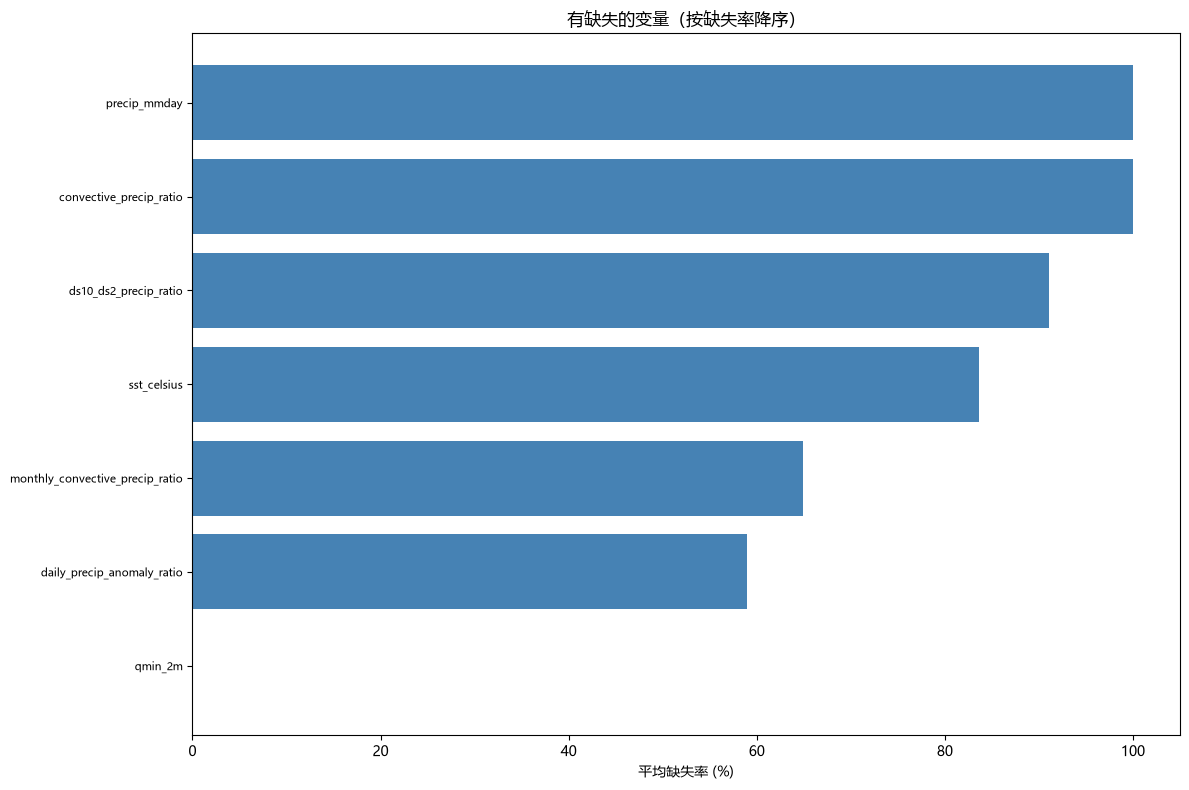

In [23]:
# 每月 15 号抽样，统计各变量缺失率
sample_dates = [f'2025-{m:02d}-15' for m in range(1, 13)]

missing_stats = {}
for date in sample_dates:
    ds = load_single_day(date)
    for v in ds.data_vars:
        if v not in missing_stats:
            missing_stats[v] = []
        arr = ds[v].values
        nan_pct = np.isnan(arr).sum() / arr.size * 100
        missing_stats[v].append(nan_pct)

missing_df = pd.DataFrame({
    'variable': list(missing_stats.keys()),
    'avg_nan_pct': [np.mean(vals) for vals in missing_stats.values()],
    'max_nan_pct': [np.max(vals) for vals in missing_stats.values()],
}).sort_values('avg_nan_pct', ascending=False)

print('=== 缺失率最高的变量 TOP 15 ===')
print(missing_df.head(15).to_string(index=False))

print(f'\n完全无缺失的变量数: {(missing_df["avg_nan_pct"] == 0).sum()}')
print(f'有缺失的变量数: {(missing_df["avg_nan_pct"] > 0).sum()}')

# 可视化缺失率
fig, ax = plt.subplots(figsize=(12, 8))
top_missing = missing_df[missing_df['avg_nan_pct'] > 0].head(30)
ax.barh(range(len(top_missing)), top_missing['avg_nan_pct'], color='steelblue')
ax.set_yticks(range(len(top_missing)))
ax.set_yticklabels(top_missing['variable'], fontsize=8)
ax.set_xlabel('平均缺失率 (%)')
ax.set_title('有缺失的变量（按缺失率降序）')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---

## 5. 关键变量描述性统计

加载一周数据，对四类灾害的核心变量计算描述统计量。

In [24]:
# 加载一周数据，覆盖冬季+夏季各半周
key_vars = [
    'daily_precip_total', 't2m_c', 'tmax_c', 'heat_index_c', 'vpd_kpa',
    'cape', 'cin', 'wind10_speed', 'wind925_speed',
    'ivt', 'pwat', 'rh2m', 'sst_celsius', 'flash_flood_risk'
]

ds_winter = load_date_range('2025-01-15', '2025-01-21', variables=key_vars, show_progress=False)
ds_summer = load_date_range('2025-07-15', '2025-07-21', variables=key_vars, show_progress=False)

print('=== 冬季 (1月15-21日) 关键变量统计 ===')
for v in key_vars:
    if v in ds_winter:
        vals = ds_winter[v].values.flatten()
        vals = vals[~np.isnan(vals)]
        print(f'{v:25s}: mean={vals.mean():10.3f}, std={vals.std():10.3f}, '
              f'min={vals.min():10.3f}, max={vals.max():10.3f}, '
              f'P95={np.percentile(vals,95):10.3f}, P99={np.percentile(vals,99):10.3f}')

print('\n=== 夏季 (7月15-21日) 关键变量统计 ===')
for v in key_vars:
    if v in ds_summer:
        vals = ds_summer[v].values.flatten()
        vals = vals[~np.isnan(vals)]
        print(f'{v:25s}: mean={vals.mean():10.3f}, std={vals.std():10.3f}, '
              f'min={vals.min():10.3f}, max={vals.max():10.3f}, '
              f'P95={np.percentile(vals,95):10.3f}, P99={np.percentile(vals,99):10.3f}')

=== 冬季 (1月15-21日) 关键变量统计 ===
daily_precip_total       : mean=     0.049, std=     0.389, min=     0.000, max=    18.125, P95=     0.000, P99=     1.500
t2m_c                    : mean=    17.705, std=     5.310, min=    -6.474, max=    30.080, P95=    26.385, P99=    27.517
tmax_c                   : mean=    22.202, std=     5.368, min=    -4.652, max=    37.365, P95=    30.053, P99=    34.240
heat_index_c             : mean=    17.752, std=     5.402, min=    -6.474, max=    30.855, P95=    26.385, P99=    29.378
vpd_kpa                  : mean=     1.212, std=     0.409, min=     0.020, max=     3.003, P95=     1.877, P99=     2.287
wind10_speed             : mean=     3.274, std=     1.957, min=     0.007, max=    12.949, P95=     7.250, P99=     9.738
rh2m                     : mean=    40.756, std=    16.485, min=     1.750, max=    96.493, P95=    72.571, P99=    79.225
sst_celsius              : mean=    24.142, std=     3.218, min=    13.267, max=    29.385, P95=    28.212, P9

---

## 6. 单变量分布可视化

对降水、温度、CAPE、风速、IVT、山洪风险绘制直方图，标注 P95/P99 极端阈值。

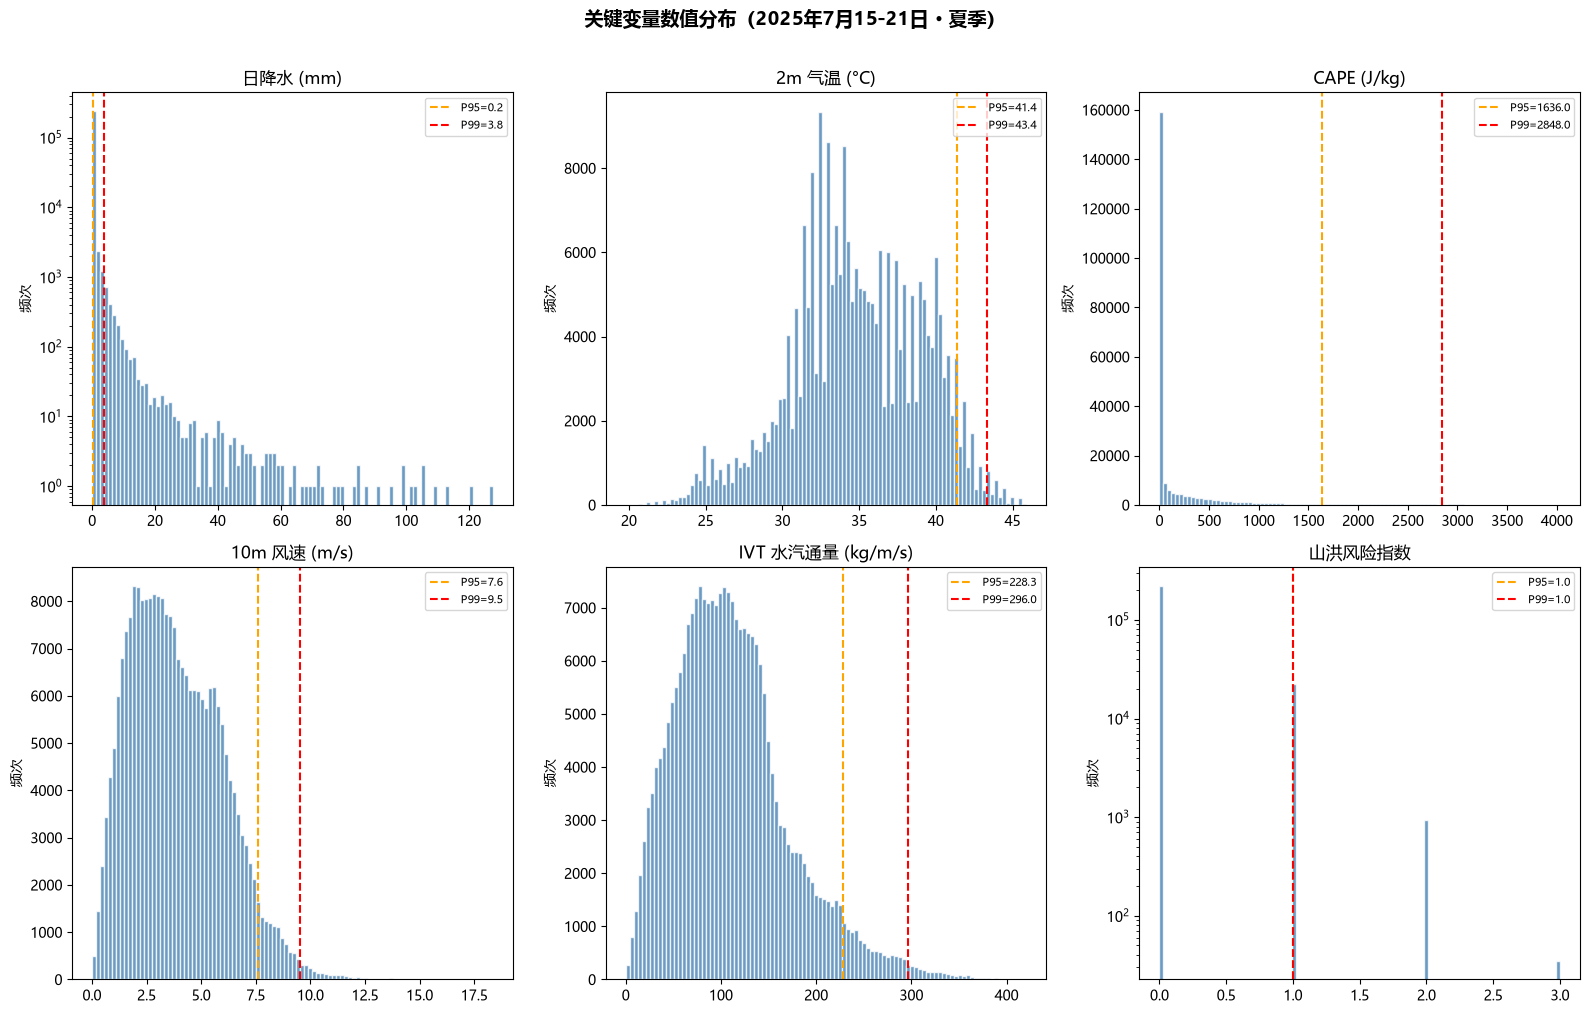

In [25]:
# 使用夏季数据绘制分布（极端事件更明显）
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

plot_config = [
    ('daily_precip_total', '日降水 (mm)', 'Blues', 'log'),
    ('t2m_c', '2m 气温 (°C)', 'Reds', 'linear'),
    ('cape', 'CAPE (J/kg)', 'Oranges', 'linear'),
    ('wind10_speed', '10m 风速 (m/s)', 'Greens', 'linear'),
    ('ivt', 'IVT 水汽通量 (kg/m/s)', 'Purples', 'linear'),
    ('flash_flood_risk', '山洪风险指数', 'Reds', 'log'),
]

for ax, (var, title, cmap, yscale) in zip(axes.flat, plot_config):
    if var in ds_summer:
        data = ds_summer[var].values.flatten()
        data = data[~np.isnan(data)]
        if len(data) == 0:
            ax.text(0.5, 0.5, 'ALL NaN', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{var} (无有效数据)')
            continue

        ax.hist(data, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
        ax.set_title(title, fontsize=12)
        ax.set_ylabel('频次')
        ax.set_yscale(yscale)

        p95 = np.percentile(data, 95)
        p99 = np.percentile(data, 99)
        ax.axvline(p95, color='orange', linestyle='--', linewidth=1.5, label=f'P95={p95:.1f}')
        ax.axvline(p99, color='red', linestyle='--', linewidth=1.5, label=f'P99={p99:.1f}')
        ax.legend(fontsize=8, loc='upper right')

plt.suptitle('关键变量数值分布（2025年7月15-21日 · 夏季）', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 7. 冬季 vs 夏季空间分布对比

对比 1 月和 7 月的气温、降水、风速的空间格局。

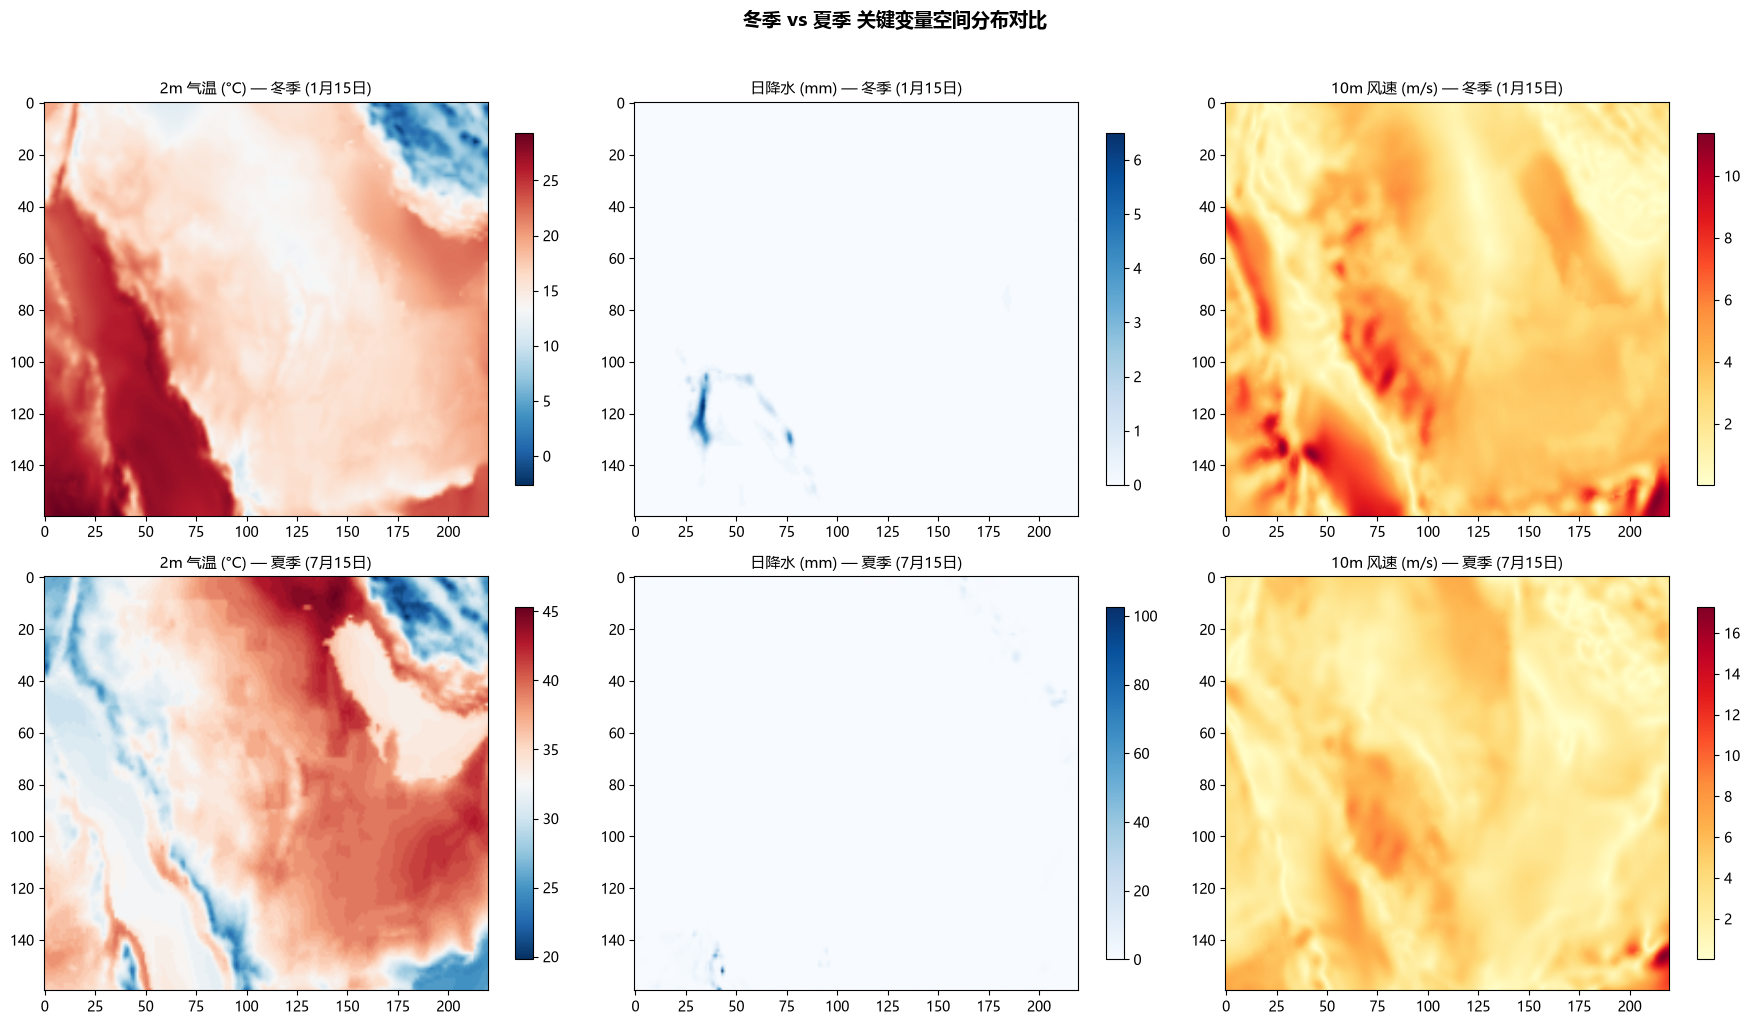


=== 区域均值对比 ===
2m 气温 (°C)          : 冬季=   17.75   夏季=   34.96   差值=  +17.20
日降水 (mm)            : 冬季=    0.03   夏季=    0.12   差值=   +0.09
10m 风速 (m/s)        : 冬季=    3.21   夏季=    3.28   差值=   +0.06


In [26]:
ds_jan = load_single_day('2025-01-15')
ds_jul = load_single_day('2025-07-15')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
compare_vars = [
    ('t2m_c', '2m 气温 (°C)', 'RdBu_r'),
    ('daily_precip_total', '日降水 (mm)', 'Blues'),
    ('wind10_speed', '10m 风速 (m/s)', 'YlOrRd'),
]

for col, (var, title, cmap) in enumerate(compare_vars):
    # 冬季
    im1 = axes[0, col].imshow(
        ds_jan[var].values, cmap=cmap, aspect='auto', origin='upper',
        interpolation='bilinear'
    )
    axes[0, col].set_title(f'{title} — 冬季 (1月15日)', fontsize=11)
    plt.colorbar(im1, ax=axes[0, col], shrink=0.85)

    # 夏季
    im2 = axes[1, col].imshow(
        ds_jul[var].values, cmap=cmap, aspect='auto', origin='upper',
        interpolation='bilinear'
    )
    axes[1, col].set_title(f'{title} — 夏季 (7月15日)', fontsize=11)
    plt.colorbar(im2, ax=axes[1, col], shrink=0.85)

plt.suptitle('冬季 vs 夏季 关键变量空间分布对比', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 数值对比
print('\n=== 区域均值对比 ===')
for var, title, _ in compare_vars:
    jan_mean = ds_jan[var].values[~np.isnan(ds_jan[var].values)].mean()
    jul_mean = ds_jul[var].values[~np.isnan(ds_jul[var].values)].mean()
    print(f'{title:20s}: 冬季={jan_mean:8.2f}   夏季={jul_mean:8.2f}   差值={jul_mean-jan_mean:+8.2f}')

---

## 8. 灾害标签分析：`flash_flood_risk`

这是当前数据中唯一的内置灾害标签。分析其正样本率、时空分布和季节规律。

正在加载全年 flash_flood_risk 数据...


加载指标文件: 100%|██████████| 365/365 [00:30<00:00, 11.91it/s]



=== flash_flood_risk 总体统计 ===
总有效样本数: 12,848,000
flash_flood_risk == 1: 928,654 (7.2280%)
flash_flood_risk > 0: 971,593 (7.5622%)
flash_flood_risk > 0.5: 971,593 (7.5622%)


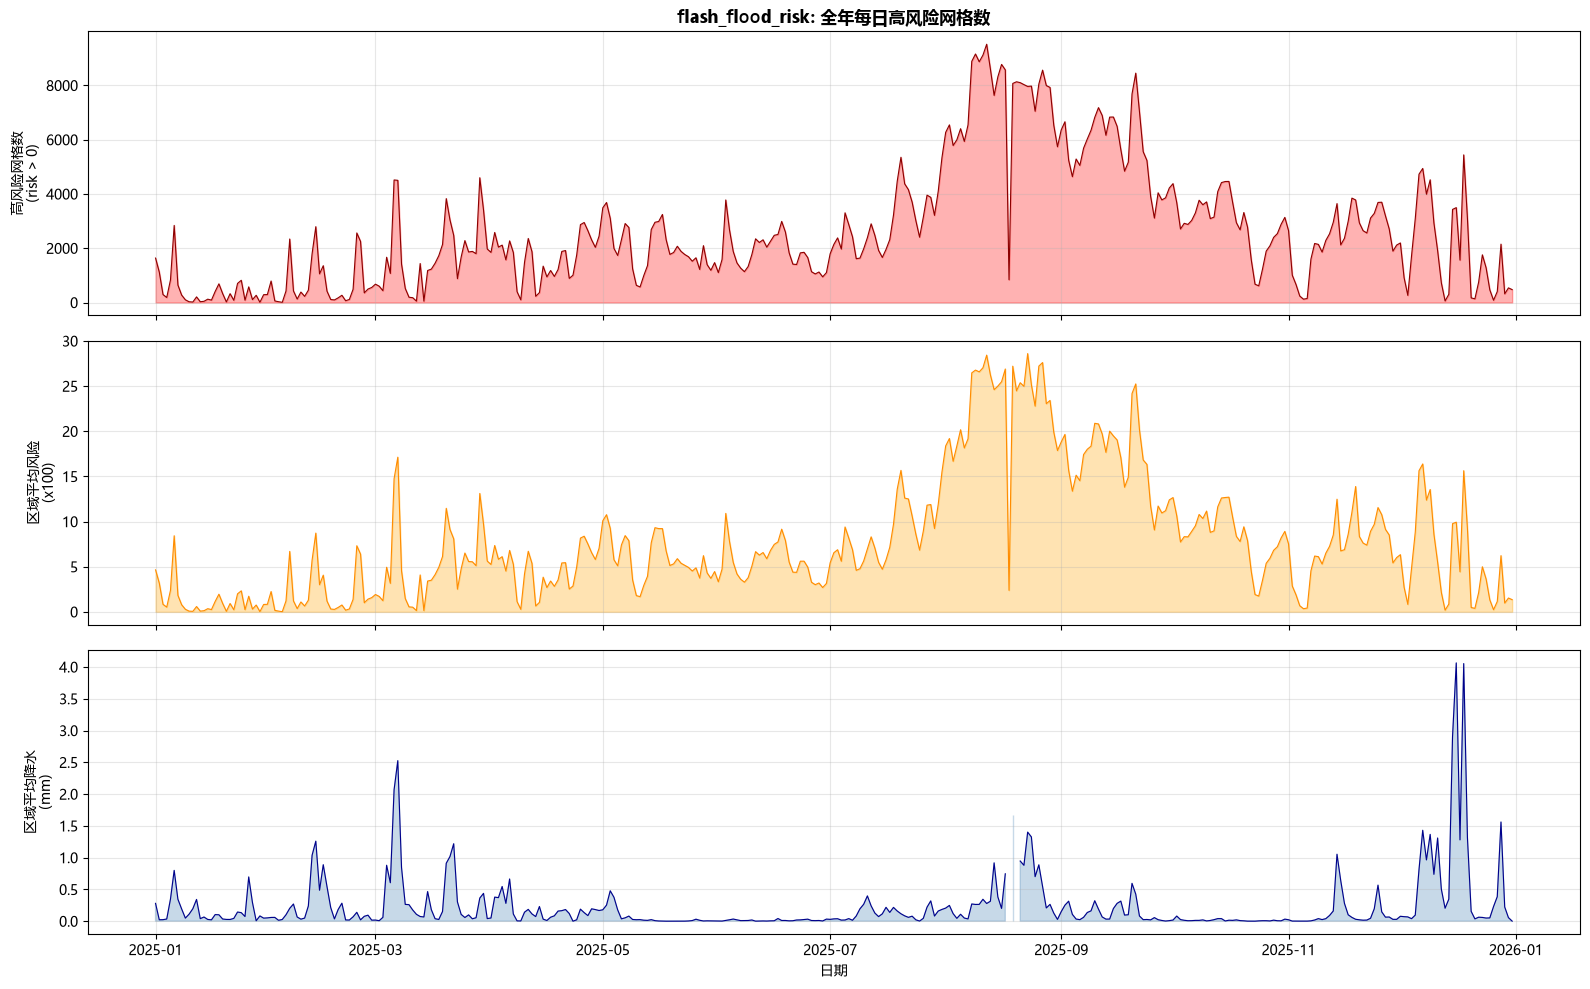


=== 月度 flash_flood_risk 汇总 ===
 month  avg_risk_cells  max_risk_cells  avg_precip
     1      435.161290            2842    0.154156
     2      723.250000            2795    0.232863
     3     1766.645161            4599    0.435003
     4     1648.066667            2949    0.165551
     5     2018.419355            3686    0.060044
     6     1836.100000            3780    0.013808
     7     2970.548387            5353    0.123046
     8     7481.161290            9517    0.475476
     9     5701.533333            8453    0.138929
    10     2970.032258            4462    0.015645
    11     2366.733333            3848    0.126049
    12     1866.709677            5441    0.790973


In [28]:
# 加载全部 365 天的 flash_flood_risk + 降水
import importlib
import data.loader
importlib.reload(data.loader)
from data.loader import load_date_range

print('正在加载全年 flash_flood_risk 数据...')
ds_year = load_date_range('2025-01-01', '2025-12-31',
                          variables=['flash_flood_risk', 'daily_precip_total'],
                          show_progress=True)

# --- 总体正样本率 ---
risk_vals = ds_year['flash_flood_risk'].values.flatten()
risk_vals = risk_vals[~np.isnan(risk_vals)]
total_cells = len(risk_vals)

print(f'\n=== flash_flood_risk 总体统计 ===')
print(f'总有效样本数: {total_cells:,}')
print(f'flash_flood_risk == 1: {(risk_vals == 1).sum():,} ({(risk_vals == 1).sum()/total_cells*100:.4f}%)')
print(f'flash_flood_risk > 0: {(risk_vals > 0).sum():,} ({(risk_vals > 0).sum()/total_cells*100:.4f}%)')
print(f'flash_flood_risk > 0.5: {(risk_vals > 0.5).sum():,} ({(risk_vals > 0.5).sum()/total_cells*100:.4f}%)')

# --- 每日时序 ---
daily_risk = ds_year['flash_flood_risk'].mean(dim=['latitude', 'longitude'])
daily_risk_count = (ds_year['flash_flood_risk'] > 0).sum(dim=['latitude', 'longitude'])
daily_precip = ds_year['daily_precip_total'].mean(dim=['latitude', 'longitude'])

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# 高风险网格占比
axes[0].fill_between(daily_risk.day.values, daily_risk_count.values, alpha=0.3, color='red')
axes[0].plot(daily_risk.day.values, daily_risk_count.values, color='darkred', linewidth=0.8)
axes[0].set_ylabel('高风险网格数\n(risk > 0)', fontsize=10)
axes[0].set_title('flash_flood_risk: 全年每日高风险网格数', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 区域平均风险
axes[1].fill_between(daily_risk.day.values, daily_risk.values * 100, alpha=0.3, color='orange')
axes[1].plot(daily_risk.day.values, daily_risk.values * 100, color='darkorange', linewidth=0.8)
axes[1].set_ylabel('区域平均风险\n(x100)', fontsize=10)
axes[1].grid(True, alpha=0.3)

# 区域平均降水
axes[2].fill_between(daily_precip.day.values, daily_precip.values, alpha=0.3, color='steelblue')
axes[2].plot(daily_precip.day.values, daily_precip.values, color='darkblue', linewidth=0.8)
axes[2].set_ylabel('区域平均降水\n(mm)', fontsize=10)
axes[2].set_xlabel('日期')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 月度汇总 ---
df_monthly = pd.DataFrame({
    'month': daily_risk.day.dt.month.values,
    'risk_count': daily_risk_count.values,
    'precip_mean': daily_precip.values,
})
monthly = df_monthly.groupby('month').agg(
    avg_risk_cells=('risk_count', 'mean'),
    max_risk_cells=('risk_count', 'max'),
    avg_precip=('precip_mean', 'mean'),
).reset_index()

print('\n=== 月度 flash_flood_risk 汇总 ===')
print(monthly.to_string(index=False))

---

## 9. 小结与下一步

### 数据概览
- ✅ **365 天完整覆盖**（2025-01-01 ~ 2025-12-31），无缺失日期
- ✅ **91 个变量**，35,200 个格点（160×220），分辨率 0.1°
- ✅ 大部分变量为日尺度 `(latitude, longitude)`，仅 `sst_celsius` 含 4 个 6-hourly 时间步

### 缺失值情况
- 大部分变量**无缺失**
- `sst_celsius` 仅在海洋格点有效（~83% NaN 在陆地上），**符合预期**
- 部分变量（如 `cape`、`daily_precip_anomaly` 等）在某些日期缺失，需要在前处理中处理

### 类别不平衡问题
- `flash_flood_risk` 正样本率极低（预计 < 0.1%），属于**严重不平衡分类问题**
- 建模时必须使用：加权损失函数、SMOTE/欠采样、或阈值优化

### 季节性特征
- 气温：冬季均值 ~17°C，夏季均值 ~35°C，空间梯度显著（南热北凉）
- 降水：全年极低，但有零星对流性暴雨事件
- 山洪风险：冬季几乎为零，集中在春末到秋季

### 下一步 (Phase 1)
1. 构建**四类灾害标签**（`data/label_builder.py`）
2. 时序特征工程（滑动窗口统计）
3. 空间特征工程（邻域聚合）
4. 训练/验证/测试集划分